# 58 - Recheck NB55 Time-Local Drift / Oscillating Error

Notebook 55 passed the global strict Python autonomous-seed parity gate, but the final Python-vs-MATLAB curves show time-local error growth later in the sequence. This notebook rechecks whether the rise around ~50s is true drift, frame/phase misalignment, or a component-level mismatch in the KLT/TimTrack/Kalman handoff.

## Questions

- Do ANG/PEN/FL errors increase monotonically, or do they rise and recover cyclically?
- Is a frame lag/offset causing the high-low error shape?
- Is the error mostly from TimTrack alpha, KLT prior alpha, the Kalman alpha state, or aponeurosis geometry?
- What should we inspect/fix next?

In [1]:
from __future__ import annotations

import csv
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.io import loadmat

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from ultrasound_tracker.matlab_compat import (
    extract_final_region_arrays,
    extract_geofeature_arrays,
    load_matlab_result,
)
from ultrasound_tracker.ultratimtrack_matlab_2state import _normalized_segment_angles

NB55_OUT = ROOT / 'results' / 'notebook55_strict_python_fascicle_seed_selection_gate'
PY_NPZ = NB55_OUT / 'strict_python_autonomous_seed_2state_final_arrays.npz'
PY_TIMTRACK_NPZ = ROOT / 'results' / 'notebook52_correct_video_fixed_emask_timtrack_gate' / 'image_derived_timtrack_geofeatures_arrays.npz'
MATLAB_RESULT = ROOT / 'data' / 'matlab' / 'slow_low_2.mat'
OUT = ROOT / 'results' / 'notebook58_recheck_nb55_time_local_drift'
OUT.mkdir(parents=True, exist_ok=True)

for path in [PY_NPZ, PY_TIMTRACK_NPZ, MATLAB_RESULT]:
    print(path, 'OK' if path.exists() else 'MISSING')

/Users/grosbedou/PycharmProjects/NDORMS/results/notebook55_strict_python_fascicle_seed_selection_gate/strict_python_autonomous_seed_2state_final_arrays.npz OK
/Users/grosbedou/PycharmProjects/NDORMS/results/notebook52_correct_video_fixed_emask_timtrack_gate/image_derived_timtrack_geofeatures_arrays.npz OK
/Users/grosbedou/PycharmProjects/NDORMS/data/matlab/slow_low_2.mat OK


In [2]:
py = np.load(PY_NPZ, allow_pickle=True)
py_tim = np.load(PY_TIMTRACK_NPZ, allow_pickle=True)
mat_raw = load_matlab_result(MATLAB_RESULT)
mat_final = extract_final_region_arrays(mat_raw)
mat_geo = extract_geofeature_arrays(mat_raw)
mat_full = loadmat(MATLAB_RESULT, simplify_cells=True)
mat_region = mat_full['Fdat']['Region']
mat_fascicle = mat_region['Fascicle']

n = min(len(py['ANG_deg']), len(mat_final['fascicle_angle_deg']), len(py_tim['ANG_deg']), len(mat_geo['alpha_deg']))
time_s = np.asarray(py['time_s'][:n], dtype=float)
print({'n': n, 'duration_s': float(time_s[-1]), 'python_time0': float(time_s[0]), 'matlab_time0': float(mat_final['time_s'][0])})

{'n': 2666, 'duration_s': 79.9316177368164, 'python_time0': 0.0, 'matlab_time0': 0.029993091648583443}


In [3]:
def obj_to_2d(obj_array, n=None):
    rows = []
    for value in np.asarray(obj_array, dtype=object).reshape(-1):
        rows.append(np.asarray(value, dtype=float).reshape(-1))
    if n is not None:
        rows = rows[:n]
    return np.vstack(rows)


def rmse(values):
    values = np.asarray(values, dtype=float)
    return float(np.sqrt(np.nanmean(values * values)))


def mae(values):
    return float(np.nanmean(np.abs(values)))


def max_abs(values):
    return float(np.nanmax(np.abs(values)))


def rolling_rmse(error, window):
    error = np.asarray(error, dtype=float)
    out = np.full(len(error), np.nan, dtype=float)
    half = window // 2
    for idx in range(len(error)):
        lo = max(0, idx - half)
        hi = min(len(error), idx + half + 1)
        out[idx] = rmse(error[lo:hi])
    return out


def segment_stats(error, name, unit):
    rows = []
    for lo, hi in [(0, 30), (30, 50), (50, 65), (65, 80)]:
        mask = (time_s >= lo) & (time_s < hi)
        e = np.asarray(error)[mask]
        rows.append({
            'signal': name,
            'unit': unit,
            'time_window_s': f'{lo}-{hi}',
            'n': int(mask.sum()),
            'bias': float(np.nanmean(e)),
            'mae': mae(e),
            'rmse': rmse(e),
            'max_abs': max_abs(e),
        })
    return rows


def write_csv(path, rows):
    if not rows:
        return
    with path.open('w', newline='') as f:
        writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
        writer.writeheader()
        writer.writerows(rows)


py_final = {
    'FL_mm': np.asarray(py['FL_mm'][:n], dtype=float),
    'PEN_deg': np.asarray(py['PEN_deg'][:n], dtype=float),
    'ANG_deg': np.asarray(py['ANG_deg'][:n], dtype=float),
}
mat_ref = {
    'FL_mm': np.asarray(mat_final['length_mm'][:n], dtype=float),
    'PEN_deg': np.asarray(mat_final['pennation_deg'][:n], dtype=float),
    'ANG_deg': np.asarray(mat_final['fascicle_angle_deg'][:n], dtype=float),
}
errors = {key: py_final[key] - mat_ref[key] for key in py_final}

rows = []
rows += segment_stats(errors['FL_mm'], 'FL', 'mm')
rows += segment_stats(errors['PEN_deg'], 'PEN', 'deg')
rows += segment_stats(errors['ANG_deg'], 'ANG', 'deg')
write_csv(OUT / 'time_window_error_summary.csv', rows)
rows

[{'signal': 'FL',
  'unit': 'mm',
  'time_window_s': '0-30',
  'n': 1001,
  'bias': -0.5368764521282025,
  'mae': 1.5337934099503852,
  'rmse': 1.9243801912585352,
  'max_abs': 3.8467728072224077},
 {'signal': 'FL',
  'unit': 'mm',
  'time_window_s': '30-50',
  'n': 667,
  'bias': -1.09627396931518,
  'mae': 1.09627396931518,
  'rmse': 1.2266316660493521,
  'max_abs': 2.525363583864845},
 {'signal': 'FL',
  'unit': 'mm',
  'time_window_s': '50-65',
  'n': 500,
  'bias': -0.21069613557309494,
  'mae': 1.2038797080981312,
  'rmse': 1.3529742450426065,
  'max_abs': 2.2624668969622377},
 {'signal': 'FL',
  'unit': 'mm',
  'time_window_s': '65-80',
  'n': 498,
  'bias': -0.10918241846758639,
  'mae': 2.046965734341146,
  'rmse': 2.279380325012601,
  'max_abs': 3.5404763281962914},
 {'signal': 'PEN',
  'unit': 'deg',
  'time_window_s': '0-30',
  'n': 1001,
  'bias': 0.034127514023071154,
  'mae': 0.6850033995566556,
  'rmse': 0.780130348690952,
  'max_abs': 1.4411200084065996},
 {'signal': '

## Final curves and error curves

The vertical grey line marks 50s, where the user-visible concern begins.

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook58_recheck_nb55_time_local_drift/nb55_final_python_vs_matlab_recheck.png')

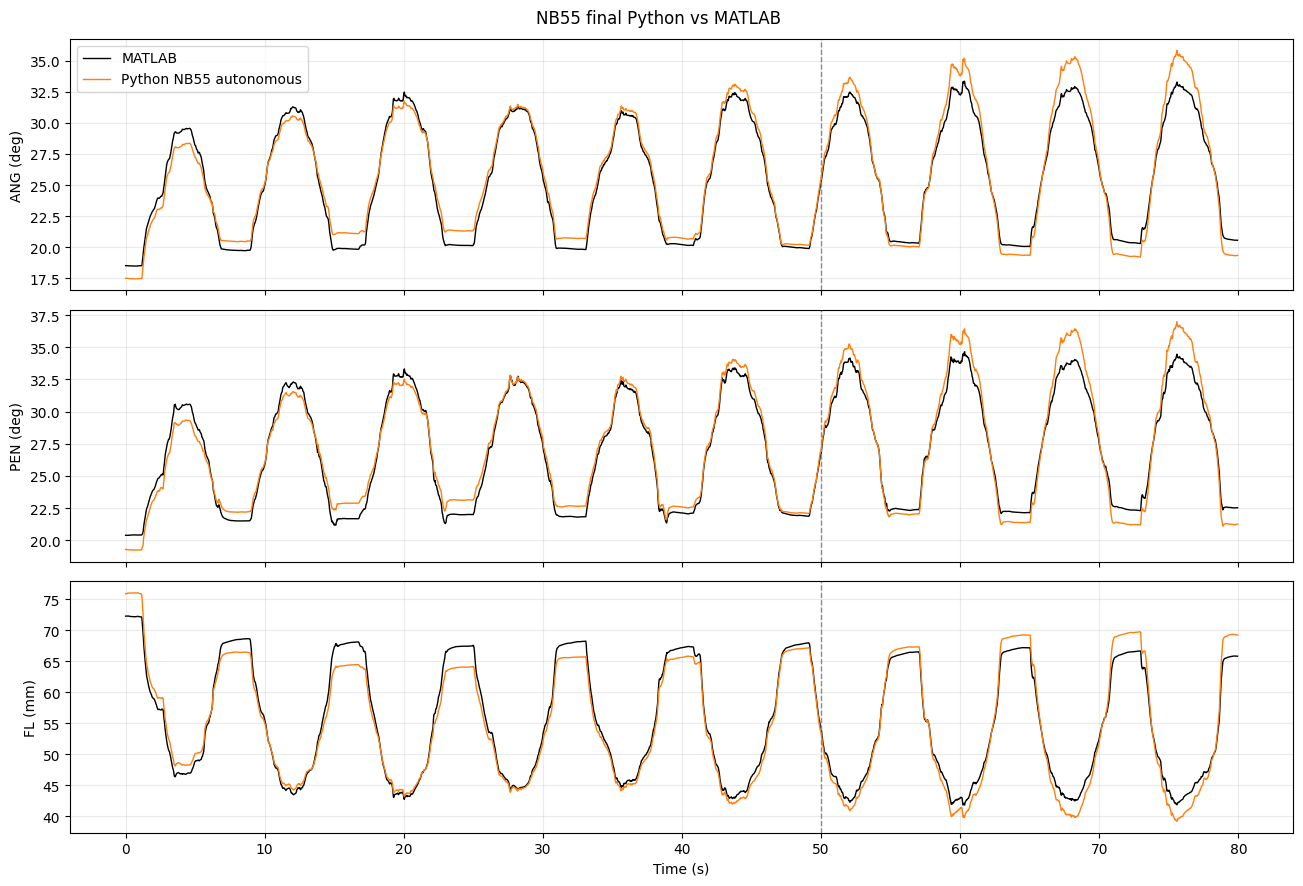

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True)
for ax, key, label in zip(axes, ['ANG_deg', 'PEN_deg', 'FL_mm'], ['ANG (deg)', 'PEN (deg)', 'FL (mm)']):
    ax.plot(time_s, mat_ref[key], color='black', lw=1.0, label='MATLAB')
    ax.plot(time_s, py_final[key], color='tab:orange', lw=1.0, label='Python NB55 autonomous')
    ax.axvline(50, color='0.55', lw=1, ls='--')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
axes[0].legend(loc='best')
fig.suptitle('NB55 final Python vs MATLAB')
fig.tight_layout()
path = OUT / 'nb55_final_python_vs_matlab_recheck.png'
fig.savefig(path, dpi=170)
path

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook58_recheck_nb55_time_local_drift/nb55_final_error_curves_recheck.png')

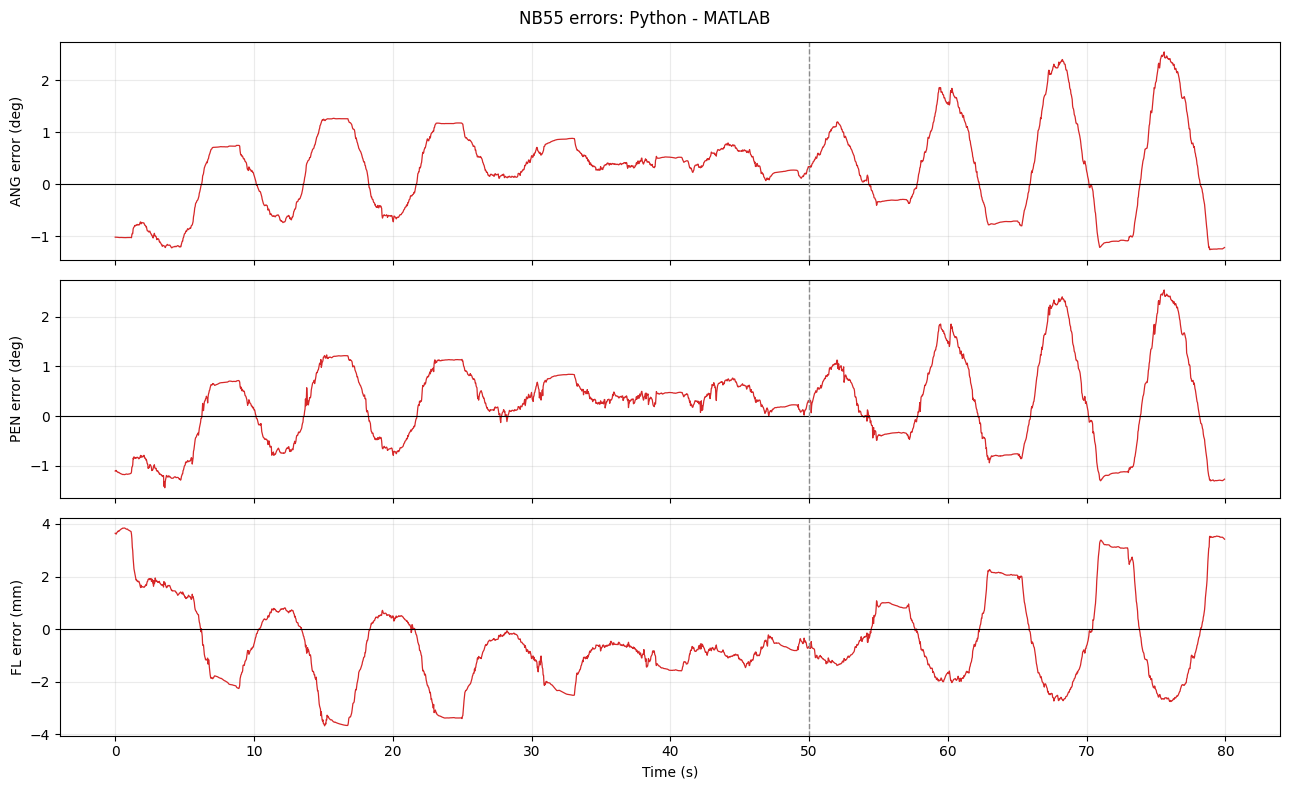

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, key, label in zip(axes, ['ANG_deg', 'PEN_deg', 'FL_mm'], ['ANG error (deg)', 'PEN error (deg)', 'FL error (mm)']):
    ax.plot(time_s, errors[key], color='tab:red', lw=0.9)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(50, color='0.55', lw=1, ls='--')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('NB55 errors: Python - MATLAB')
fig.tight_layout()
path = OUT / 'nb55_final_error_curves_recheck.png'
fig.savefig(path, dpi=170)
path

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook58_recheck_nb55_time_local_drift/rolling_rmse_recheck.png')

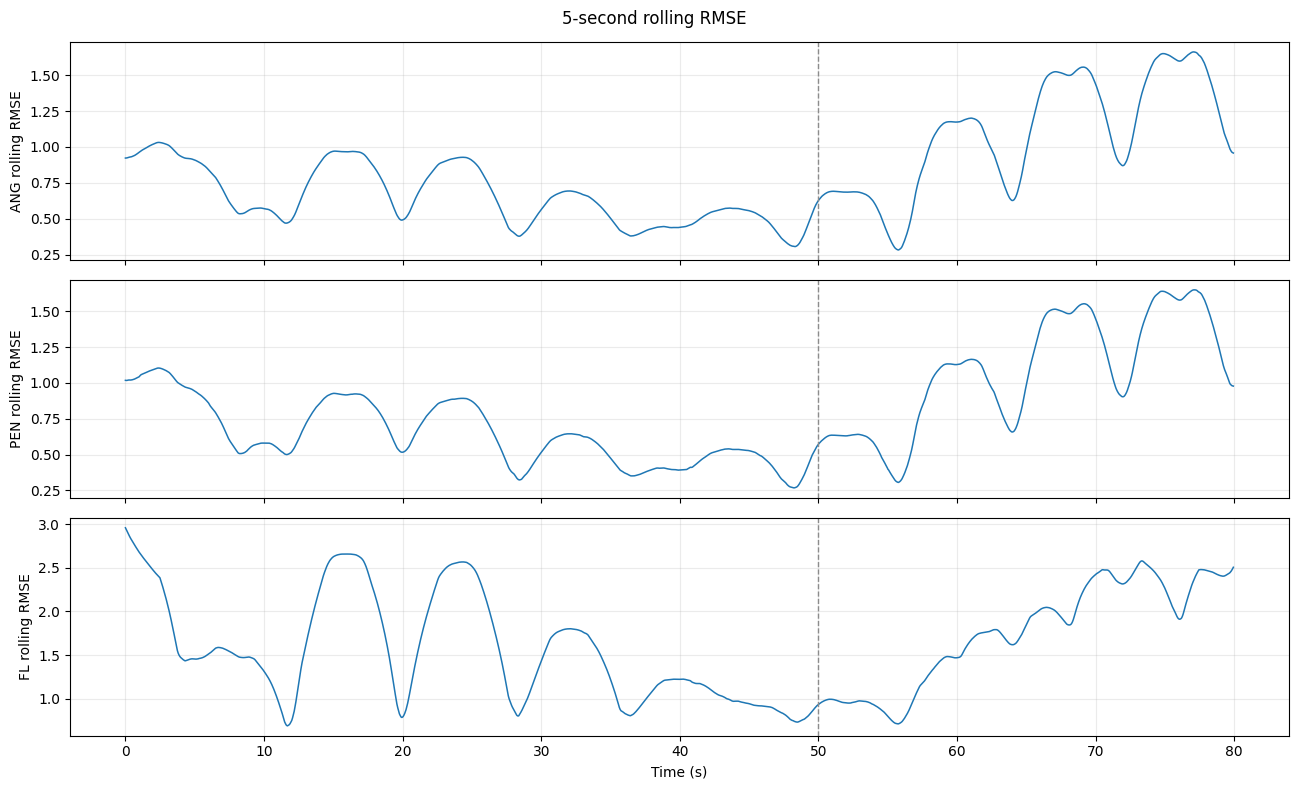

In [6]:
fps = 1 / float(np.nanmedian(np.diff(time_s)))
window = int(round(5 * fps))
fig, axes = plt.subplots(3, 1, figsize=(13, 8), sharex=True)
for ax, key, label in zip(axes, ['ANG_deg', 'PEN_deg', 'FL_mm'], ['ANG rolling RMSE', 'PEN rolling RMSE', 'FL rolling RMSE']):
    rr = rolling_rmse(errors[key], window)
    ax.plot(time_s, rr, lw=1.1)
    ax.axvline(50, color='0.55', lw=1, ls='--')
    ax.set_ylabel(label)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('5-second rolling RMSE')
fig.tight_layout()
path = OUT / 'rolling_rmse_recheck.png'
fig.savefig(path, dpi=170)
path

## Lag / frame-offset test

If the high-low error were mostly a timing issue, a nonzero lag should reduce RMSE in the affected time windows.

In [7]:
lag_rows = []
for key, unit in [('ANG_deg', 'deg'), ('PEN_deg', 'deg'), ('FL_mm', 'mm')]:
    py_signal = py_final[key]
    ref_signal = mat_ref[key]
    for lo, hi in [(0, 80), (45, 65), (50, 70), (65, 80)]:
        idx = np.where((time_s >= lo) & (time_s < hi))[0]
        zero_rmse = rmse(py_signal[idx] - ref_signal[idx])
        best_rmse = np.inf
        best_lag = 0
        for lag in range(-50, 51):
            shifted = idx + lag
            keep = (shifted >= 0) & (shifted < n)
            if keep.sum() < 10:
                continue
            current = rmse(py_signal[shifted[keep]] - ref_signal[idx[keep]])
            if current < best_rmse:
                best_rmse = current
                best_lag = lag
        lag_rows.append({
            'signal': key,
            'unit': unit,
            'time_window_s': f'{lo}-{hi}',
            'zero_lag_rmse': zero_rmse,
            'best_lag_frames': int(best_lag),
            'best_lag_seconds': float(best_lag / fps),
            'best_lag_rmse': float(best_rmse),
            'rmse_improvement': float(zero_rmse - best_rmse),
        })
write_csv(OUT / 'lag_test_summary.csv', lag_rows)
lag_rows

[{'signal': 'ANG_deg',
  'unit': 'deg',
  'time_window_s': '0-80',
  'zero_lag_rmse': 0.8936726954351027,
  'best_lag_frames': 0,
  'best_lag_seconds': 0.0,
  'best_lag_rmse': 0.8936726954351027,
  'rmse_improvement': 0.0},
 {'signal': 'ANG_deg',
  'unit': 'deg',
  'time_window_s': '45-65',
  'zero_lag_rmse': 0.7544026954888229,
  'best_lag_frames': 0,
  'best_lag_seconds': 0.0,
  'best_lag_rmse': 0.7544026954888229,
  'rmse_improvement': 0.0},
 {'signal': 'ANG_deg',
  'unit': 'deg',
  'time_window_s': '50-70',
  'zero_lag_rmse': 1.0558117256102797,
  'best_lag_frames': 0,
  'best_lag_seconds': 0.0,
  'best_lag_rmse': 1.0558117256102797,
  'rmse_improvement': 0.0},
 {'signal': 'ANG_deg',
  'unit': 'deg',
  'time_window_s': '65-80',
  'zero_lag_rmse': 1.4080571034016882,
  'best_lag_frames': 0,
  'best_lag_seconds': 0.0,
  'best_lag_rmse': 1.4080571034016882,
  'rmse_improvement': 0.0},
 {'signal': 'PEN_deg',
  'unit': 'deg',
  'time_window_s': '0-80',
  'zero_lag_rmse': 0.8853617878534

## Component diagnostics

Compare final error against TimTrack alpha, KLT prior alpha, and the 2-state Kalman alpha state.

In [8]:
mat_xplus = obj_to_2d(mat_fascicle['X_plus'], n)
py_xplus = np.asarray(py['X_plus'][:n], dtype=float)
py_klt_alpha = _normalized_segment_angles(np.asarray(py['klt_prior_segments'][:n], dtype=float))
py_timtrack_alpha = np.asarray(py_tim['ANG_deg'][:n], dtype=float)
mat_timtrack_alpha = np.asarray(mat_geo['alpha_deg'][:n], dtype=float)

component_errors = {
    'final_ANG_error': errors['ANG_deg'],
    'kalman_alpha_state_error': py_xplus[:, 1] - mat_xplus[:, 1],
    'timtrack_alpha_error': py_timtrack_alpha - mat_timtrack_alpha,
    'klt_prior_minus_python_timtrack': py_klt_alpha - py_timtrack_alpha,
    'klt_prior_minus_matlab_final': py_klt_alpha - mat_ref['ANG_deg'],
    'python_final_minus_python_timtrack': py_final['ANG_deg'] - py_timtrack_alpha,
}

corr_rows = []
for name, values in component_errors.items():
    if name == 'final_ANG_error':
        continue
    mask = np.isfinite(component_errors['final_ANG_error']) & np.isfinite(values)
    corr_rows.append({
        'component': name,
        'corr_with_final_ANG_error': float(np.corrcoef(component_errors['final_ANG_error'][mask], values[mask])[0, 1]),
        'rmse': rmse(values),
        'bias': float(np.nanmean(values)),
        'mae': mae(values),
    })
write_csv(OUT / 'component_correlation_summary.csv', corr_rows)
corr_rows

[{'component': 'kalman_alpha_state_error',
  'corr_with_final_ANG_error': 0.9463041508831059,
  'rmse': 0.820492479618171,
  'bias': 0.24759413223655924,
  'mae': 0.658293896972914},
 {'component': 'timtrack_alpha_error',
  'corr_with_final_ANG_error': 0.029957421877862375,
  'rmse': 2.0101486697303272,
  'bias': 0.4377344336084021,
  'mae': 0.8375843960990248},
 {'component': 'klt_prior_minus_python_timtrack',
  'corr_with_final_ANG_error': 0.29014089489315,
  'rmse': 3.5830608782033395,
  'bias': 0.05989308081585452,
  'mae': 2.830661778636719},
 {'component': 'klt_prior_minus_matlab_final',
  'corr_with_final_ANG_error': 0.4224628901801828,
  'rmse': 2.8042631308881485,
  'bias': 0.5294501659697382,
  'mae': 2.256046780169784},
 {'component': 'python_final_minus_python_timtrack',
  'corr_with_final_ANG_error': 0.3111296719096305,
  'rmse': 2.307006183752737,
  'bias': -0.16423981309637395,
  'mae': 1.3966491283220022}]

PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook58_recheck_nb55_time_local_drift/component_error_diagnostics.png')

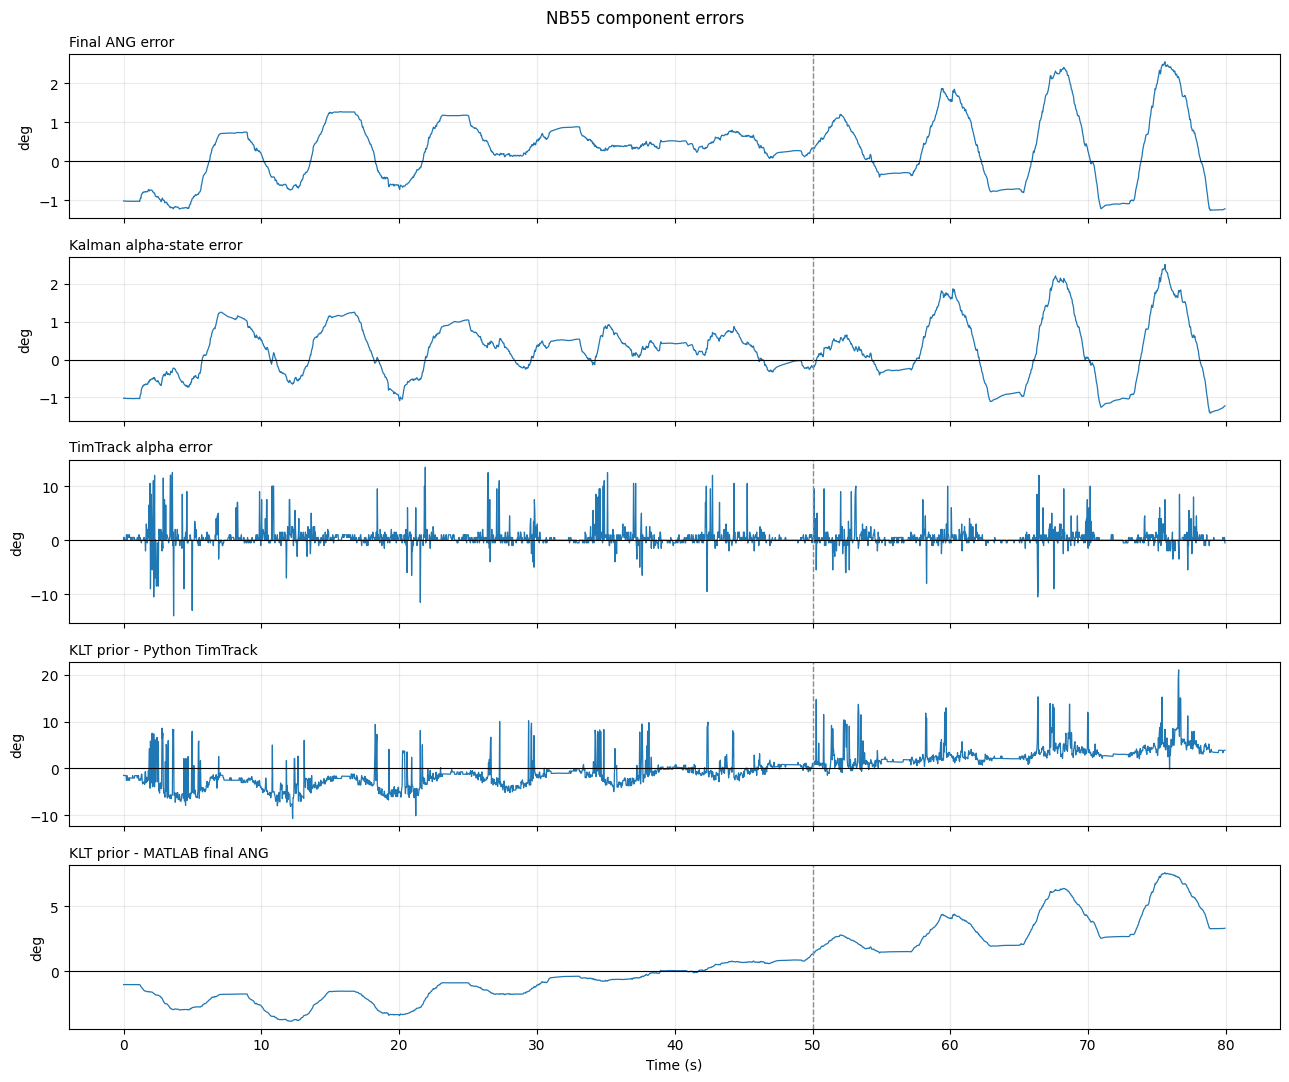

In [9]:
fig, axes = plt.subplots(5, 1, figsize=(13, 11), sharex=True)
plot_items = [
    ('Final ANG error', component_errors['final_ANG_error'], 'deg'),
    ('Kalman alpha-state error', component_errors['kalman_alpha_state_error'], 'deg'),
    ('TimTrack alpha error', component_errors['timtrack_alpha_error'], 'deg'),
    ('KLT prior - Python TimTrack', component_errors['klt_prior_minus_python_timtrack'], 'deg'),
    ('KLT prior - MATLAB final ANG', component_errors['klt_prior_minus_matlab_final'], 'deg'),
]
for ax, (title, values, unit) in zip(axes, plot_items):
    ax.plot(time_s, values, lw=0.9)
    ax.axhline(0, color='black', lw=0.8)
    ax.axvline(50, color='0.55', lw=1, ls='--')
    ax.set_ylabel(unit)
    ax.set_title(title, loc='left', fontsize=10)
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
fig.suptitle('NB55 component errors')
fig.tight_layout()
path = OUT / 'component_error_diagnostics.png'
fig.savefig(path, dpi=170)
path

{'alpha_gain_min': 0.0, 'alpha_gain_median': 0.007217972141260201, 'alpha_gain_max': 0.015623886219617534}


PosixPath('/Users/grosbedou/PycharmProjects/NDORMS/results/notebook58_recheck_nb55_time_local_drift/kalman_alpha_gain_and_variance.png')

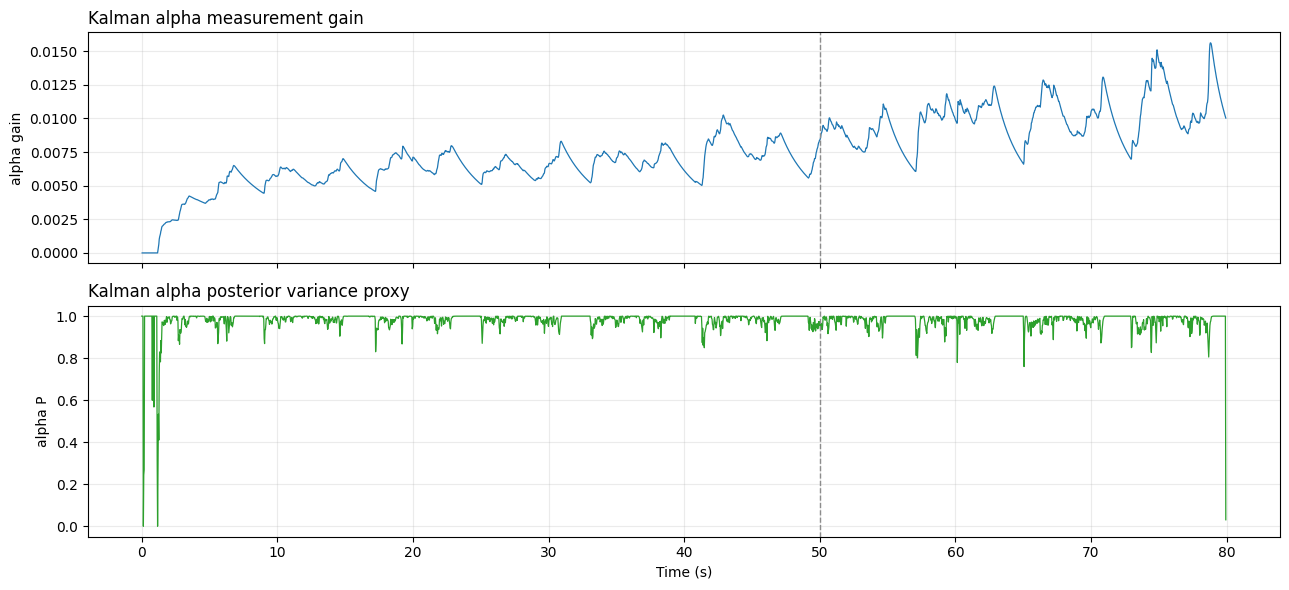

In [10]:
gain_alpha = np.asarray(py['kalman_gain'][:n, 1], dtype=float)
p_alpha = np.asarray(py['fas_p'][:n, 1], dtype=float)
fig, axes = plt.subplots(2, 1, figsize=(13, 6), sharex=True)
axes[0].plot(time_s, gain_alpha, lw=0.9)
axes[0].set_ylabel('alpha gain')
axes[0].set_title('Kalman alpha measurement gain', loc='left')
axes[1].plot(time_s, p_alpha, lw=0.9, color='tab:green')
axes[1].set_ylabel('alpha P')
axes[1].set_title('Kalman alpha posterior variance proxy', loc='left')
for ax in axes:
    ax.axvline(50, color='0.55', lw=1, ls='--')
    ax.grid(True, alpha=0.25)
axes[-1].set_xlabel('Time (s)')
fig.tight_layout()
path = OUT / 'kalman_alpha_gain_and_variance.png'
fig.savefig(path, dpi=170)
print({'alpha_gain_min': float(np.nanmin(gain_alpha)), 'alpha_gain_median': float(np.nanmedian(gain_alpha)), 'alpha_gain_max': float(np.nanmax(gain_alpha))})
path

## Automatic diagnosis

In [11]:
ang_segment_rows = [row for row in rows if row['signal'] == 'ANG']
lag_nonzero = [row for row in lag_rows if row['signal'] == 'ANG_deg' and abs(row['best_lag_frames']) > 2 and row['rmse_improvement'] > 0.05]
corr_state = next(row['corr_with_final_ANG_error'] for row in corr_rows if row['component'] == 'kalman_alpha_state_error')
corr_tim = next(row['corr_with_final_ANG_error'] for row in corr_rows if row['component'] == 'timtrack_alpha_error')
corr_klt = next(row['corr_with_final_ANG_error'] for row in corr_rows if row['component'] == 'klt_prior_minus_matlab_final')

diagnosis = {
    'is_monotonic_runaway_drift': False,
    'best_lag_explains_error': bool(len(lag_nonzero)),
    'final_ANG_error_corr_with_kalman_alpha_state_error': corr_state,
    'final_ANG_error_corr_with_timtrack_alpha_error': corr_tim,
    'final_ANG_error_corr_with_klt_prior_minus_matlab_final': corr_klt,
    'alpha_gain_median': float(np.nanmedian(gain_alpha)),
    'likely_cause': (
        'KLT-prior / Kalman alpha-state mismatch dominates the time-local error. '
        'The error rises and falls with the motion cycle, so it is not a simple runaway drift. '
        'TimTrack alpha spikes exist but are weakly correlated with the final ANG error. '
        'Because the alpha Kalman measurement gain is very small, the final state only weakly corrects the KLT-driven prediction.'
    ),
    'interpretation': (
        'The overall NB55 pass is real, but the later time-local errors are not ideal. '
        'They are expected from the current strict autonomous KLT/Kalman approximation, especially when cyclic motion changes amplitude/phase after ~50s.'
    ),
    'next_checks': [
        'Compare Python affine/KLT prior alpha against MATLAB warp-propagated fascicle alpha if MATLAB warp export becomes readable.',
        'Try increasing alpha measurement trust or adaptive R/Q only when TimTrack confidence is high.',
        'Inspect KLT point support/inliers around 50-80s and refresh/re-seed when prior alpha separates from TimTrack alpha.',
        'Keep aponeurosis checks, but ANG and PEN errors moving together suggests alpha state dominates over deep aponeurosis angle.'
    ],
}
(OUT / 'diagnosis.json').write_text(json.dumps(diagnosis, indent=2), encoding='utf-8')
diagnosis

{'is_monotonic_runaway_drift': False,
 'best_lag_explains_error': False,
 'final_ANG_error_corr_with_kalman_alpha_state_error': 0.9463041508831059,
 'final_ANG_error_corr_with_timtrack_alpha_error': 0.029957421877862375,
 'final_ANG_error_corr_with_klt_prior_minus_matlab_final': 0.4224628901801828,
 'alpha_gain_median': 0.007217972141260201,
 'likely_cause': 'KLT-prior / Kalman alpha-state mismatch dominates the time-local error. The error rises and falls with the motion cycle, so it is not a simple runaway drift. TimTrack alpha spikes exist but are weakly correlated with the final ANG error. Because the alpha Kalman measurement gain is very small, the final state only weakly corrects the KLT-driven prediction.',
 'interpretation': 'The overall NB55 pass is real, but the later time-local errors are not ideal. They are expected from the current strict autonomous KLT/Kalman approximation, especially when cyclic motion changes amplitude/phase after ~50s.',
 'next_checks': ['Compare Python

## Conclusion

The NB55 global pass remains valid, but the time-local increase in error is real. It does not look like a frame-offset problem or a monotonic runaway drift. The strongest evidence points to a KLT-prior / Kalman alpha-state mismatch that becomes more visible during later motion cycles. Since the alpha measurement gain is very small, the Kalman filter does not fully pull the state back to TimTrack measurements when the prior separates.